# TestBench

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Recommendation_Engine_tinker") \
    .getOrCreate()

bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)
bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)
26/03/05 05:07:10 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/05 05:07:11 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 05:07:11 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Pleas

In [2]:
date = "2026-02-25"
path_to_data = f"gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day={date}"
df = spark.read.parquet(path_to_data)

In [3]:
df.printSchema()

root
 |-- cp_content_id: string (nullable = true)
 |-- play_time_outliers_flag: string (nullable = true)
 |-- playablecontent_year: string (nullable = true)
 |-- actor: string (nullable = true)
 |-- source_rail_position: string (nullable = true)
 |-- events_city: string (nullable = true)
 |-- city: string (nullable = true)
 |-- cp_name: string (nullable = true)
 |-- deviceId: string (nullable = true)
 |-- content_genres: string (nullable = true)
 |-- content_tags: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- record_updated_timestamp: timestamp (nullable = true)
 |-- app_session_id: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- bn: string (nullable = true)
 |-- curr_play_time_min: double (nullable = true)
 |-- content_series_id: string (nullable = true)
 |-- dt: string (nullable = true)
 |-- channel_name: string (nullable = true)
 |-- rebuffer_time_outliers_flag: string (nullable = true)
 |-- c

In [4]:
print(df.limit(1).collect()[0].asDict())

26/03/05 05:07:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


{'cp_content_id': '362', 'play_time_outliers_flag': 'no', 'playablecontent_year': None, 'actor': 'Tulika Basu|Koel Mullick', 'source_rail_position': None, 'events_city': 'Mumbai', 'city': '', 'cp_name': 'ADDATIMES', 'deviceId': '2b42c2cb163a0ff9', 'content_genres': 'Action|Comedy|Drama|Romance', 'content_tags': None, 'record_updated_timestamp': None, 'app_session_id': '', 'genre': None, 'timestamp': '1772021030110', 'bn': '276', 'curr_play_time_min': 0.0, 'content_series_id': None, 'dt': 'TV', 'channel_name': None, 'rebuffer_time_outliers_flag': 'no', 'content_segment': 'ATVPLUS', 'programme_id': None, 'playablecontent_livetype': None, 'sports_sub_type': None, 'online': 'online', 'content_ua': 1772019286610, 'description': "The film begins with Dev (Dev), a college student, meeting Rimi (Koel Mallick)– a girl who comes from the U.S. to take admission in 'Princeton' College for completing her papers. She becomes a matter of rivalry between Dev and his rival in college, Ronnie, whom Dev 

In [5]:
# import pyspark.sql.functions as F

# # 1. Grab exactly 50 random rows from your massive dataset
# print("Fetching 100 random rows...")
# sample_df = df.orderBy(F.rand()).limit(100)

# # 2. Convert those 100 rows into a local Pandas dataframe
# pdf = sample_df.toPandas()

# # 3. Save it as a CSV file right here in your VSCode workspace
# csv_filename = "data_discovery_sample.csv"
# pdf.to_csv(csv_filename, index=False)

# print(f"Done! Open '{csv_filename}' in VSCode to view the table.")

In [6]:
columns = [
    "cp_name", "dt",
    "content_segment", "content_type",
    "content_channel_id", "content_channel_name",
    "content_content_type"
]

for c in columns:
    print(f"\nDistinct values for {c}:")
    df.select(c).distinct().show(50, truncate=False)


Distinct values for cp_name:


+-------------+
|cp_name      |
+-------------+
|HUNGAMA      |
|STAGE        |
|KLIKK        |
|ADDATIMES    |
|SONYLIV_VOD  |
|VROTT        |
|EPICON       |
|NAMMAFLIX    |
|TIMESPLAY    |
|DOLLYWOOD    |
|LIONSGATEPLAY|
|PLAYFLIX     |
|ZEEFIVE      |
|RUNNTV       |
|ULTRA        |
|RAJTV        |
|SHEMAROOME   |
|SHORTSTV     |
|AHA          |
|MINITV       |
|HOICHOI      |
|DISTROTV     |
|MANORAMAMAX  |
|CHANAJOR     |
|CHAUPAL      |
|DOCUBAY      |
|EROSNOW      |
|ALTBALAJI    |
|ZEEDIGITAL   |
|MWTV         |
|LIVETV       |
|HOTSTAR_DTH  |
|SUNNXT       |
|XSTREAMADS   |
|KANCCHALANKA |
|AMAZON_PRIME |
|NULL         |
+-------------+


Distinct values for dt:


+-------+
|dt     |
+-------+
|TV     |
|tvOS   |
|PHONE  |
|tablet |
|phone  |
|TABLET |
|BROWSER|
|STB    |
|STICK  |
|NULL   |
+-------+


Distinct values for content_segment:


+---------------+
|content_segment|
+---------------+
|ATVPLUS        |
|NULL           |
+---------------+


Distinct values for content_type:


+------------+
|content_type|
+------------+
|VOD         |
|URL         |
|NULL        |
+------------+


Distinct values for content_channel_id:


+------------------------------------------+
|content_channel_id                        |
+------------------------------------------+
|TIMESPLAY_LIVECHANNEL_channel_32          |
|TIMESPLAY_LIVECHANNEL_channel_30          |
|DISTROTV_LIVETVCHANNEL_3613               |
|RUNNTV_LIVECHANNEL_41                     |
|RUNNTV_LIVECHANNEL_7                      |
|DISTROTV_LIVETVCHANNEL_3176               |
|RUNNTV_LIVECHANNEL_6                      |
|ZEEDIGITAL_LIVETVCHANNEL_ZEE_NEWS         |
|ZEEDIGITAL_LIVETVCHANNEL_WION             |
|TIMESPLAY_LIVECHANNEL_channel_28          |
|ZEEDIGITAL_LIVETVCHANNEL_ZEE_BUSINESS     |
|TIMESPLAY_LIVECHANNEL_channel_24          |
|DISTROTV_LIVETVCHANNEL_1744               |
|DISTROTV_LIVETVCHANNEL_4996               |
|RUNNTV_LIVECHANNEL_11                     |
|DISTROTV_LIVETVCHANNEL_2889               |
|RUNNTV_LIVECHANNEL_40                     |
|DISTROTV_LIVETVCHANNEL_4109               |
|RUNNTV_LIVECHANNEL_4                      |
|RUNNTV_LI

+----------------------------------------------+
|content_channel_name                          |
+----------------------------------------------+
|Spring Escape                                 |
|9X Jalwa                                      |
|Terribly Tiny Tales                           |
|Zee News                                      |
|NH BollyRaga                                  |
|MNX - HD                                      |
|ROMEDY NOW                                    |
|Runn Action                                   |
|ET NOW                                        |
|NAVBHARAT                                     |
|WION                                          |
|Zee Business                                  |
|Pocket Films                                  |
|Shemaroo Bollywood                            |
|Mastiii - India's No.1 Music and Youth Channel|
|Runn Thrillers                                |
|News9Live                                     |
|TV9 Marathi        

+--------------------+
|content_content_type|
+--------------------+
|TRAILER             |
|LIVETVCHANNEL       |
|MOVIE               |
|EPISODE             |
|VIDEO               |
|TVSHOW              |
|SEASON              |
|NULL                |
+--------------------+



filtered database with live-tv removoed

In [7]:
# import pyspark.sql.functions as F

# streamable_df = (
#     df.select(
#         "userId","cp_content_id", "cp_name", "curr_play_time_min",
#         "content_series_id","episode_id", "playtime",
#         "content_series_name", "content_category",
#         "streams_flag_final", "content_season_id",
#         "playablecontent_ty", "duration_secs",
#         "content_t", "event_type", "user_session_id",
#         "playablecontent_epinum", "total_play_time_sec",
#         "playablecontent_tvsid", "playablecontent_sid",
#         "episode_number", "content_content_type",
#         "content_id", "play_session_id", "day"
#     )
#     .filter(
#         F.col("content_content_type").isin(
#             "MOVIE", "EPISODE", "VIDEO", "TVSHOW", "SEASON"
#         )
#     )
#     .sample(fraction=0.001, seed=42).limit(100)
# )

# print("Fetching 100 random rows for streamable content...")

# # sample_df = streamable_df.orderBy(F.rand()).limit(100)

# pdf = sample_df.toPandas()

# csv_filename = "streamable_cleaned.csv"
# pdf.to_csv(csv_filename, index=False)

# print(f"Done! Open '{csv_filename}' in VSCode to view the table.")

In [ ]:
import pyspark.sql.functions as F

streamable_df = (
    df.select(
        "userId","cp_content_id", "cp_name", "curr_play_time_min",
        "content_series_id","episode_id", "playtime",
        "content_series_name", "content_category",
        "streams_flag_final", "content_season_id",
        "playablecontent_ty", "duration_secs",
        "content_t", "event_type", "user_session_id",
        "playablecontent_epinum", "total_play_time_sec",
        "playablecontent_tvsid", "playablecontent_sid",
        "episode_number", "content_content_type",
        "content_id", "play_session_id", "day"
    )
    .filter(
        F.col("content_content_type").isin(
            "MOVIE", "EPISODE", "VIDEO", "TVSHOW", "SEASON"
        )
    )
)

print("No of rows in streamable_df:", streamable_df.count())

print("Fetching 100 random rows for streamable content...")


pdf = streamable_df.sample(fraction=0.001, seed=42).limit(100).toPandas()

csv_filename = "streamable_cleaned.csv"
pdf.to_csv(csv_filename, index=False)

print(f"Done! Open '{csv_filename}' in VSCode to view the table.")

No of rows in streamable_df: 1872836
Fetching 100 random rows for streamable content...


Done! Open 'streamable_cleaned.csv' in VSCode to view the table.


In [ ]:
content_df = df.select("content_id", "content_title", 
                       "cp_content_id", "cp_name", "content_category", 
                       "content_series_name", "content_season_id", 
                       "episode_number", "content_content_type").distinct()

Checking if the dataset has same user having multiple entries and what they look like.

In [9]:
import pyspark.sql.functions as F

# 1. Users with multiple rows
multi_users = (
    streamable_df
    .groupBy("userId")
    .count()
    .filter(F.col("count") > 1)
)

# 2. Pick random users
random_users = (
    multi_users
    .orderBy(F.rand())
    .limit(10)
    .select("userId")
)

# 3. Get all logs
result = (
    streamable_df
    .join(random_users, "userId")
    .orderBy("userId")
)

result.show(200, truncate=False)

26/03/05 05:08:10 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


+------------------+-------------------------------------------------+-------------+-------------------+---------------------------------------------------------------+----------+---------------------+-------------------------------+----------------+------------------+------------------------------------------------------------------------------------------------------------------------+------------------+-------------+----------------------------------+--------------------+--------------------------------------------------+----------------------+-------------------+---------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------+--------------+--------------------+----------------------------------------------------------------+------------------------------------+----------+
|userId            |cp_content_id                                    |cp_name      |curr_pla

In [10]:
multi_users.orderBy(F.desc("count")).show(10)
print(multi_users.count())

+------------------+-----+
|            userId|count|
+------------------+-----+
|lUxxHj73TDGhtVUhe0|  823|
|zQpEepL5zH0Wy68Et0|  704|
|OXZaZsRq9lCUXhPxu0|  690|
|QuBqkE45XKdcluQpM0|  618|
|UneQneV-ElZ9X15su0|  538|
|S71DVjlcA6dZYT5VB0|  527|
|wy-QC9uTHBX2RuZ_g0|  409|
|g9oSULISiUCT-iKH80|  409|
|lDy_MtJ6psCoOXBKG0|  355|
|RDxr5s2r2ZqKboIII0|  326|
+------------------+-----+
only showing top 10 rows



328888


In [11]:
print(result.count())

26/03/05 05:08:21 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


70


### Trying to combine duplicate play times

In [12]:
import pyspark.sql.functions as F
#userid","user_session_id", "cp_content_id", "content_series_id", "episode_id", "content_id", "play_session_id" 
combined_playtime = (
    streamable_df
    .groupBy("userid", "cp_content_id", "content_series_id", "episode_id", "content_id",)
    .agg(
        F.sum("total_play_time_sec").alias("total_playtime_combined"),
        F.count("*").alias("num_sessions")
    )
)

print("original row-count  :", streamable_df.cache().count())
print("Aggregated row-count:", combined_playtime.count())
combined_playtime.filter(F.col("num_sessions")>1).sample(fraction=0.001, seed=42).limit(10).show(truncate=False)

original row-count  : 1872836


Aggregated row-count: 1387349
+------------------+-------------------------------------------------+---------------------------------------------------------------+----------+----------------------------------------------------------------+-----------------------+------------+
|userid            |cp_content_id                                    |content_series_id                                              |episode_id|content_id                                                      |total_playtime_combined|num_sessions|
+------------------+-------------------------------------------------+---------------------------------------------------------------+----------+----------------------------------------------------------------+-----------------------+------------+
|UK8eU1nqSnGkW3jBw0|HANCOCKY2008MTA                                  |NULL                                                           |NULL      |LIONSGATEPLAY_MOVIE_HANCOCKY2008MTA                             |1063.817        

### test

In [13]:
print(combined_playtime.filter(F.col("num_sessions")>1).count())

309608


In [14]:
streamable_df.groupBy("user_session_id") \
    .agg(F.countDistinct("userid").alias("num_users")) \
    .filter(F.col("num_users") > 1) \
    .show(20, False)

+--------------------------------------------------+---------+
|user_session_id                                   |num_users|
+--------------------------------------------------+---------+
|NULL                                              |58972    |
|442893d3-c3c4-4da9-9fe7-f713e5050170-1772011758714|2        |
|f353fe5e-d7ba-429a-920a-80e54b5ccf22-1771972130413|2        |
|1ffc02e3-2feb-4e4b-b035-eb9d8cd7608e-1772025134883|2        |
|46833301-1771960565589                            |2        |
|6ffecb2d-43b5-4677-bbdd-768758f8a93e-1772023520984|2        |
|9be91452-4801-4aaf-a6fb-0d245244bcb2-1771959118619|2        |
|                                                  |27       |
|e09e15f3-5f14-4ca4-90ca-4b149a428ba7-1771986493512|2        |
|24853fef-df4e-4abf-85fa-cb1fd8b50854-1772034915243|2        |
|67821938-1772004990433                            |2        |
|21576993-1772024537347                            |2        |
|e2361841-1746-467f-a200-e4c0395707c5-1772023521354|2  

In [15]:
null_count = streamable_df.filter(F.col("userid").isNull()).count()
print(f"Number of NA values in 'userId': {null_count}")

streamable_xnul_df = streamable_df.na.drop(subset=["userId"])

Number of NA values in 'userId': 0


### Understanding data

In [16]:
sample_df = combined_playtime.sample(0.01).select("total_playtime_combined")
pdf = sample_df.toPandas()

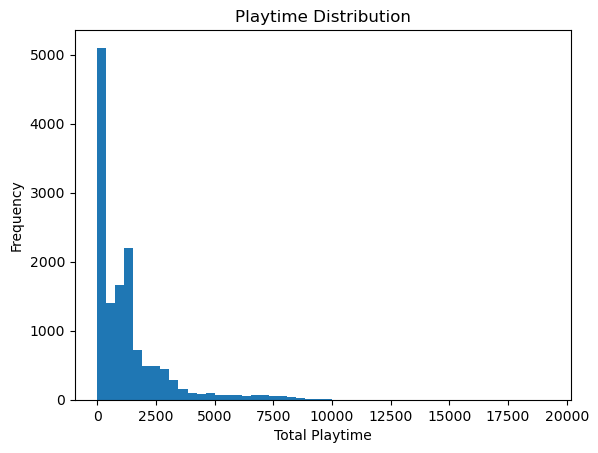

In [17]:
import matplotlib.pyplot as plt

plt.hist(pdf["total_playtime_combined"], bins=50)
plt.xlabel("Total Playtime")
plt.ylabel("Frequency")
plt.title("Playtime Distribution")

plt.show()

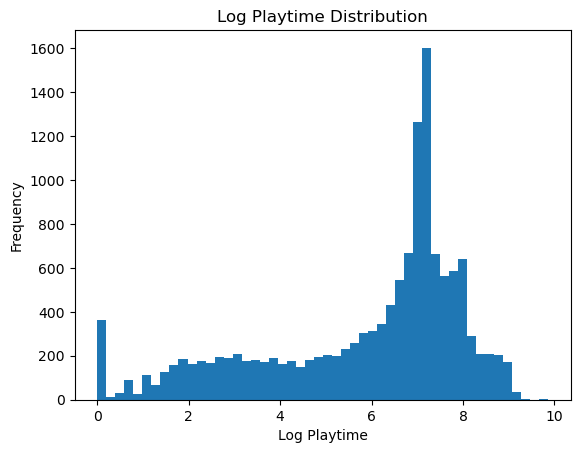

In [18]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(np.log1p(pdf["total_playtime_combined"]), bins=50)

plt.xlabel("Log Playtime")
plt.ylabel("Frequency")
plt.title("Log Playtime Distribution")

plt.show()

In [19]:
combined_playtime.approxQuantile(
    "total_playtime_combined",
    [0.25,0.5,0.75,0.9,0.99],
    0.01
)

[80.343, 866.0, 1524.12, 2938.14, 91936.0]

In [20]:
print("Error watchtimers count:", streamable_df.filter(F.col("total_play_time_sec") > 2963).count())

Error watchtimers count: 121408


### Zscore Normalisation

In [21]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window

w = Window.partitionBy("userid")

user_normalized = combined_playtime.withColumn(
    "user_mean",
    F.mean("total_playtime_combined").over(w)
).withColumn(
    "user_std",
    F.stddev("total_playtime_combined").over(w)
).withColumn("playtime_log", F.log1p("total_playtime_combined")
).withColumn(
    "playtime_z_user",
    (
        F.col("total_playtime_combined") - F.col("user_mean")
    ) / F.col("user_std")
)
user_normalized.sample(fraction=0.001, seed=42).limit(10).show(truncate=False)

+------------------+-------------------------------------------------+---------------------------------------------------------------+----------+----------------------------------------------------------------+-----------------------+------------+------------------+------------------+------------------+--------------------+
|userid            |cp_content_id                                    |content_series_id                                              |episode_id|content_id                                                      |total_playtime_combined|num_sessions|user_mean         |user_std          |playtime_log      |playtime_z_user     |
+------------------+-------------------------------------------------+---------------------------------------------------------------+----------+----------------------------------------------------------------+-----------------------+------------+------------------+------------------+------------------+--------------------+
|4PJon56aIDk1Gjyxa0|10

In [22]:
user_normalized = user_normalized.withColumn(
    "user_likes",
    F.when(F.col("playtime_z_user") > 1, 1).otherwise(0)
)

user_normalized.orderBy(F.col("userid"))
user_normalized.show(100)

+------------------+--------------------+--------------------+----------+--------------------+-----------------------+------------+------------------+------------------+------------------+--------------------+----------+
|            userid|       cp_content_id|   content_series_id|episode_id|          content_id|total_playtime_combined|num_sessions|         user_mean|          user_std|      playtime_log|     playtime_z_user|user_likes|
+------------------+--------------------+--------------------+----------+--------------------+-----------------------+------------+------------------+------------------+------------------+--------------------+----------+
|--17p0Yk5D3V9JME40|              173483|                NULL|      NULL|MANORAMAMAX_MOVIE...|                 1120.0|           1|            1999.5| 1243.800828107137|  7.02197642307216| -0.7071067811865476|         0|
|--17p0Yk5D3V9JME40|              176956|                NULL|      NULL|MANORAMAMAX_MOVIE...|                 2879.


## Implementing ALS

#### changing string to int

In [23]:
from pyspark.ml.feature import StringIndexer
user_indexer = StringIndexer(
    inputCol="userid",
    outputCol="userIndex"
)

item_indexer = StringIndexer(
    inputCol="content_id",
    outputCol="itemIndex"
)

als_data = user_indexer.fit(user_normalized).transform(user_normalized)
als_data = item_indexer.fit(als_data).transform(als_data)

26/03/05 05:08:40 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


Removing null values for a quick fix

In [25]:
als_data = als_data.filter(
    F.col("playtime_log").isNotNull()
).filter(
    ~F.isnan("playtime_log")
)

Training ALS model

In [ ]:
from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="userIndex",
    itemCol="itemIndex",
    ratingCol="playtime_log", #using log because of skewness in playtime distribution
    implicitPrefs=True,
    rank=20,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop"
)

model = als.fit(als_data)

26/03/05 05:13:45 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:47 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:48 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:49 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:51 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:53 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:54 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:55 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:56 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:57 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:13:58 WARN DAGScheduler: Broadcasting large task binary with size 24.8 MiB
26/03/05 05:14:01 WARN DAGScheduler: Broadc

In [27]:
recommendations = model.recommendForAllUsers(10)

In [28]:
recommendations.show(10, truncate=False)

26/03/05 05:15:22 WARN DAGScheduler: Broadcasting large task binary with size 24.9 MiB
26/03/05 05:15:50 WARN DAGScheduler: Broadcasting large task binary with size 24.9 MiB


+---------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|userIndex|recommendations                                                                                                                                                                                       |
+---------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|65       |[{33, 0.20254992}, {21, 0.1997014}, {7, 0.17420995}, {73, 0.16053447}, {43, 0.15179998}, {42, 0.14152604}, {35, 0.1315046}, {26, 0.12990327}, {12, 0.12100572}, {87, 0.120268054}]                    |
|133      |[{11, 0.09630922}, {13, 0.09240446}, {39, 0.060616296}, {48, 0.059049904}, {58, 0.05774899}, {59, 0.039629906}, {150, 0.03351473}, {234, 0.030968

26/03/05 05:17:13 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 7 for reason Executor for container container_1764236692086_4515_01_000007 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 05:17:13 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 8 for reason Executor for container container_1764236692086_4515_01_000008 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 05:17:19 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 5 for reason Executor for container container_1764236692086_4515_01_000005 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 05:17:19 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 6 for reason Executor for container container_1764236692086_4515_

## Extracting readable recommendations

In [29]:
import pyspark.sql.functions as F

rec_exploded = recommendations.select(
    "userIndex",
    F.explode("recommendations").alias("rec")
)
rec_exploded = rec_exploded.select(
    "userIndex",
    F.col("rec.itemIndex"),
    F.col("rec.rating")
)

In [30]:
user_lookup = als_data.select("userid", "userIndex").distinct()
item_lookup = als_data.select("content_id", "itemIndex").distinct()

final_recommendations = rec_exploded \
    .join(user_lookup, "userIndex") \
    .join(item_lookup, "itemIndex")

In [ ]:
final_recommendations.orderBy(
    "userid",
    F.desc("rating")
).show(50, False)

26/03/05 06:13:01 WARN DAGScheduler: Broadcasting large task binary with size 24.9 MiB
26/03/05 06:13:11 WARN DAGScheduler: Broadcasting large task binary with size 21.0 MiB
26/03/05 06:13:11 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/03/05 06:13:15 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/03/05 06:13:16 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/05 06:13:19 WARN DAGScheduler: Broadcasting large task binary with size 21.0 MiB
26/03/05 06:13:24 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/05 06:13:58 WARN SparkConf: The configuration key 'spark.yarn.execu

+---------+---------+------------+------------------+----------------------------------------------------------------+
|itemIndex|userIndex|rating      |userid            |content_id                                                      |
+---------+---------+------------+------------------+----------------------------------------------------------------+
|7        |2834     |0.64749587  |                  |MINITV_EPISODE_amzn1.dv.gti.aca0c1e0-4914-4d9f-afac-3d0fce82f02f|
|43       |2834     |0.5481479   |                  |AHA_MOVIE_2E7ED81D-F684-482E-A253-4F4740C65E6C                  |
|33       |2834     |0.52904654  |                  |AHA_MOVIE_0F598AED-27BE-451B-8B5D-3609D0A43767                  |
|64       |2834     |0.4692953   |                  |AHA_MOVIE_56C857B8-BCAB-45FE-8946-35565EC13532                  |
|12       |2834     |0.40692398  |                  |AHA_MOVIE_DF73946B-2E13-48C6-9686-34319F678307                  |
|42       |2834     |0.39930332  |              

26/03/05 06:15:36 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 18 for reason Executor for container container_1764236692086_4515_01_000018 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 06:15:36 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 16 for reason Executor for container container_1764236692086_4515_01_000016 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 06:15:36 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 17 for reason Executor for container container_1764236692086_4515_01_000017 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 06:15:36 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 15 for reason Executor for container container_1764236692086_4

In [32]:
watched = user_normalized.select("userid", "content_id")

final_recommendations = final_recommendations.join(
    watched,
    ["userid", "content_id"],
    "left_anti"
)   

In [33]:
window = Window.partitionBy("userid").orderBy(F.desc("rating"))

final_recommendations = final_recommendations.withColumn(
    "rank",
    F.row_number().over(window)
).filter("rank <= 5")

In [34]:
final_recommendations.orderBy("userid", "rank").show(100, False)

26/03/05 06:21:19 WARN DAGScheduler: Broadcasting large task binary with size 24.9 MiB
26/03/05 06:21:29 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/03/05 06:21:30 WARN DAGScheduler: Broadcasting large task binary with size 21.0 MiB
26/03/05 06:21:34 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/05 06:21:39 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/03/05 06:21:40 WARN DAGScheduler: Broadcasting large task binary with size 21.0 MiB
26/03/05 06:21:41 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/05 06:21:42 WARN SparkConf: The configuration key 'spark.yarn.execu

+------------------+----------------------------------------------------------------+---------+---------+------------+----+
|userid            |content_id                                                      |itemIndex|userIndex|rating      |rank|
+------------------+----------------------------------------------------------------+---------+---------+------------+----+
|                  |AHA_MOVIE_2E7ED81D-F684-482E-A253-4F4740C65E6C                  |43       |2834     |0.5481479   |1   |
|                  |AHA_MOVIE_DF73946B-2E13-48C6-9686-34319F678307                  |12       |2834     |0.40692398  |2   |
|                  |AHA_MOVIE_27EE2557-078B-4890-B70F-66C79649F97F                  |42       |2834     |0.39930332  |3   |
|                  |SONYLIV_VOD_MOVIE_1090503578                                    |3        |2834     |0.39592326  |4   |
|                  |AHA_MOVIE_91B37D19-AF75-4184-884F-7C2EC2809368                  |21       |2834     |0.3360815   |5   |
|--03-Va

26/03/05 06:23:02 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 43 for reason Executor for container container_1764236692086_4515_01_000055 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 06:23:02 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 44 for reason Executor for container container_1764236692086_4515_01_000056 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 06:23:32 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 19 for reason Executor for container container_1764236692086_4515_01_000019 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 06:23:32 WARN YarnAllocator: Container from a bad node: container_1764236692086_4515_01_000022 on host: dprc-wynk-prd-data-ds-machine-learning-common-sw-dmqc

## Organising Results

In [36]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F

w_user = Window.partitionBy("userid").orderBy(F.desc("total_playtime_combined"))

top_watched = (
    user_normalized
    .withColumn("rank_watched", F.row_number().over(w_user))
    .filter(F.col("rank_watched") <= 5)
    .select(
        "userid",
        F.col("content_id").alias("watched_content_id"),
        "rank_watched"
    )
)

In [37]:
w_reco = Window.partitionBy("userid").orderBy(F.desc("rating"))

top_reco = (
    final_recommendations
    .withColumn("rank_reco", F.row_number().over(w_reco))
    .filter(F.col("rank_reco") <= 5)
    .select(
        "userid",
        F.col("content_id").alias("reco_content_id"),
        "rank_reco"
    )
)

In [38]:
comparison_table = (
    top_watched.alias("w")
    .join(
        top_reco.alias("r"),
        (F.col("w.userid") == F.col("r.userid")) &
        (F.col("w.rank_watched") == F.col("r.rank_reco")),
        "inner"
    )
    .select(
        F.col("w.userid").alias("userId"),
        "watched_content_id",
        "rank_watched",
        "reco_content_id",
        F.col("rank_reco")
    )
)

In [39]:
comparison_table.orderBy("userId","rank_watched").show(100, False)

26/03/05 06:45:04 WARN DAGScheduler: Broadcasting large task binary with size 24.9 MiB
26/03/05 06:45:15 WARN DAGScheduler: Broadcasting large task binary with size 21.0 MiB
26/03/05 06:45:16 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/03/05 06:45:17 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/05 06:45:18 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/03/05 06:45:19 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/05 06:45:19 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in

+------------------+----------------------------------------------------------------+------------+----------------------------------------------------------------+---------+
|userId            |watched_content_id                                              |rank_watched|reco_content_id                                                 |rank_reco|
+------------------+----------------------------------------------------------------+------------+----------------------------------------------------------------+---------+
|                  |MANORAMAMAX_MOVIE_150639                                        |1           |AHA_MOVIE_2E7ED81D-F684-482E-A253-4F4740C65E6C                  |1        |
|                  |AHA_MOVIE_56C857B8-BCAB-45FE-8946-35565EC13532                  |2           |AHA_MOVIE_DF73946B-2E13-48C6-9686-34319F678307                  |2        |
|                  |SONYLIV_VOD_MOVIE_1000281665                                    |3           |AHA_MOVIE_27EE2557-078B-4890-B70

26/03/05 06:46:55 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 56 for reason Executor for container container_1764236692086_4515_01_000071 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 06:47:25 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 50 for reason Executor for container container_1764236692086_4515_01_000064 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 06:47:25 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 55 for reason Executor for container container_1764236692086_4515_01_000069 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/05 06:47:25 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 54 for reason Executor for container container_1764236692086_4

# TestBench2